In [1]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
!pip install xgboost



Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 85.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.7/291.7 MB 90.5 MB/s eta 0:00:0000:0100:01


In [2]:
import sys
!{sys.executable} -m pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 87.7 MB/s eta 0:00:00


In [2]:
import sys
!{sys.executable} -m pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Load the train, validation, and test data
train = np.load("../CNN/data/processed/train.npz")
val = np.load("../CNN/data/processed/val.npz")
test = np.load("../CNN/data/processed/test.npz")


X_train, y_train = train['x'], train['y']
X_val, y_val = val['x'], val['y']
X_test, y_test = test['x'], test['y']
print("done")

done


In [3]:
# If image data is 2D, flatten it
if len(X_train.shape) > 2:
    X_train = X_train.reshape((X_train.shape[0], -1))
    X_val = X_val.reshape((X_val.shape[0], -1))
    X_test = X_test.reshape((X_test.shape[0], -1))

print("Flattened X_train shape:", X_train.shape)


Flattened X_train shape: (54000, 784)


In [4]:
X_combined = np.concatenate((X_train, X_val), axis=0)
y_combined = np.concatenate((y_train, y_val), axis=0)
print("done")

done


In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

In [6]:
model = XGBClassifier(eval_metric='mlogloss', n_jobs=-1)
model.fit(X_combined, y_combined)

print("done")

done


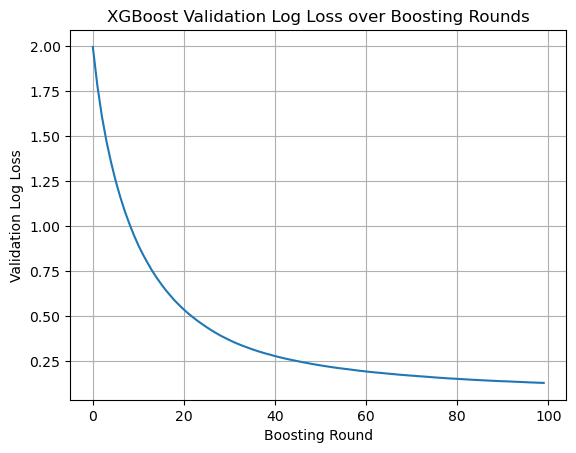

In [15]:
import xgboost as xgb

# Convert to DMatrix (XGBoost’s native data format)
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

params = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'num_class': 10,
    'max_depth': 5,
    'learning_rate': 0.1
}

evals_result = {}
booster = xgb.train(
    params,
    dtrain,
    num_boost_round=100,
    evals=[(dval, 'Validation')],
    evals_result=evals_result,
    verbose_eval=False
)

# Plot validation loss over rounds
plt.plot(evals_result['Validation']['mlogloss'])
plt.title("XGBoost Validation Log Loss over Boosting Rounds")
plt.xlabel("Boosting Round")
plt.ylabel("Validation Log Loss")
plt.grid(True)
plt.show()


In [7]:
# Predict class labels and probabilities
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)

# Evaluation metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
auc = roc_auc_score(y_test_bin, y_pred_prob, average='macro', multi_class='ovr')

print("Accuracy:", round(acc, 4))
print("F1 Score (macro):", round(f1, 4))
print("AUC Score (macro, OVR):", round(auc, 4))


Accuracy: 0.9368
F1 Score (macro): 0.9362
AUC Score (macro, OVR): 0.9969


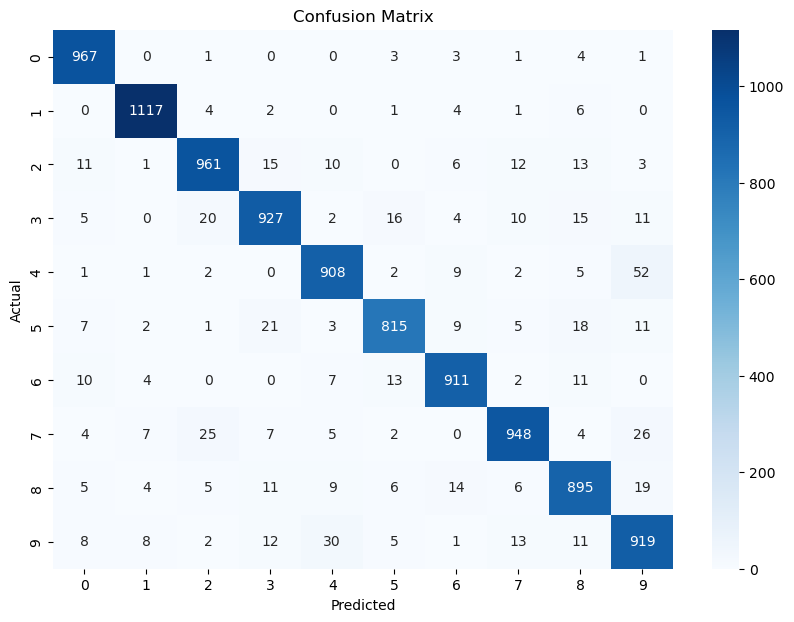

In [8]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


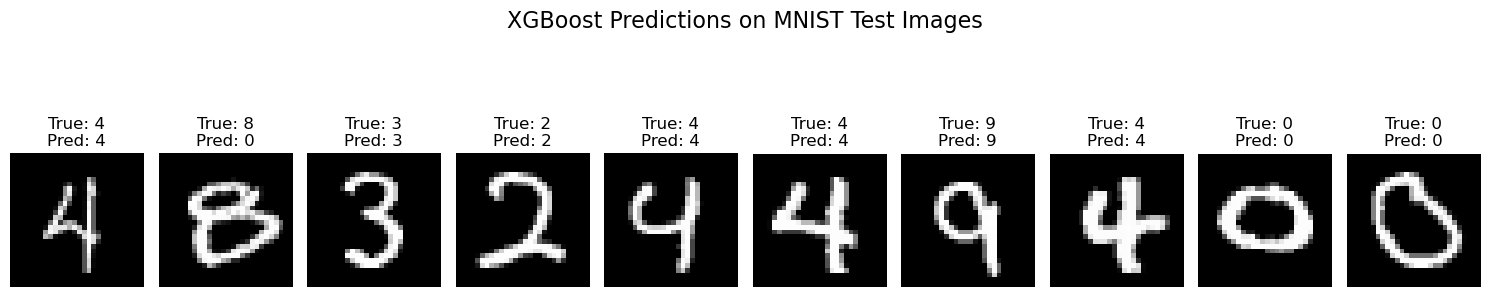

In [9]:
import matplotlib.pyplot as plt

# Choose N random test samples to display
N = 10
indices = np.random.choice(len(X_test), N, replace=False)

fig, axes = plt.subplots(1, N, figsize=(15, 4))
fig.suptitle("XGBoost Predictions on MNIST Test Images", fontsize=16)

for i, idx in enumerate(indices):
    # Reshape the flat image back to 28x28 for display
    image = X_test[idx].reshape(28, 28)
    true_label = y_test[idx]
    predicted_label = y_pred[idx]
    
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [11]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Light parameter grid for quick tuning
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2]
}

# Use CPU-friendly 'hist' instead of GPU
tuned_model = XGBClassifier(tree_method='hist', eval_metric='mlogloss')

# Use a smaller subset of data to prevent memory issues
X_subset = X_combined[:10000]
y_subset = y_combined[:10000]

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=tuned_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=2  # or 1 if needed
)

# Run the search
grid_search.fit(X_subset, y_subset)

# Get the best estimator
best_model = grid_search.best_estimator_

# Retrain best model on full training data (optional)
best_model.fit(X_combined, y_combined)

# Predict on test data
y_pred_tuned = best_model.predict(X_test)
y_pred_prob_tuned = best_model.predict_proba(X_test)

# Evaluate tuned model
acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')
auc_tuned = roc_auc_score(lb.transform(y_test), y_pred_prob_tuned, average='macro', multi_class='ovr')

# Print results
print("✅ Best Parameters:", grid_search.best_params_)
print("Tuned Accuracy:", round(acc_tuned, 4))
print("Tuned F1 Score (macro):", round(f1_tuned, 4))
print("Tuned AUC Score (macro, OVR):", round(auc_tuned, 4))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
Tuned Accuracy: 0.9752
Tuned F1 Score (macro): 0.9751
Tuned AUC Score (macro, OVR): 0.9995


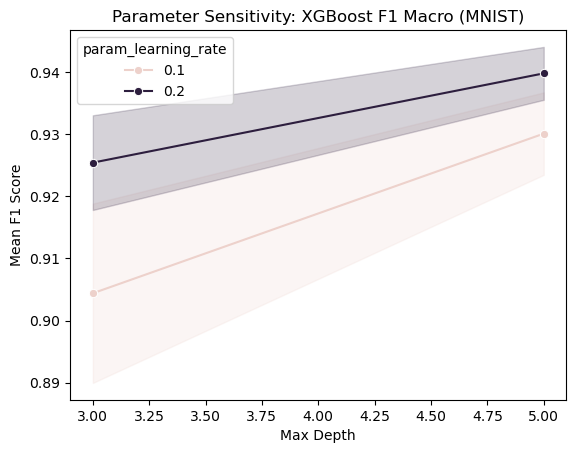

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dummy example — replace with your actual grid search results
results_df = pd.DataFrame(grid_search.cv_results_)

# Plot accuracy/F1 as a function of hyperparameters
sns.lineplot(
    data=results_df,
    x="param_max_depth",
    y="mean_test_score",
    hue="param_learning_rate",
    marker="o"
)
plt.title("Parameter Sensitivity: XGBoost F1 Macro (MNIST)")
plt.ylabel("Mean F1 Score")
plt.xlabel("Max Depth")
plt.show()
